## Example of do classification with SKNano Framework

### Xgboost

#### 1. Import the necessary libraries

In this part, Let's try to perform a classification using Xgboost.

You have to import the necessary libraries. In this case, I think it enforces to use package manager like conda. Try to import the necessary libraries. If you don't have the necessary libraries, you can install them using the following command, like this:

```bash
conda install -c conda-forge xgboost
```

In [1]:
import ROOT
import numpy as np
import pandas as pd
import xgboost as xgb
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import confusion_matrix
import onnx
from onnxmltools.convert.xgboost.operator_converters.XGBoost import convert_xgboost
from onnxmltools.convert import convert_xgboost as convert_xgboost_booster
from onnxmltools.convert.common.data_types import FloatTensorType, DoubleTensorType

#### 2. Change ROOT Dataset to Pandas DataFrame

In most cases, starting from numpy array is the easiest way to start. ROOT support conversion of TTree to numpy array using RDataFrame.

In [2]:
# enter your tree path here:
path_sig = "/data9/Users/eunsu/SKNanoOutput/MLExample/RunTreeMake/2024/TTLL_powheg.root" #TTLL
path_bkg = "/data9/Users/eunsu/SKNanoOutput/MLExample/RunTreeMake/2024/DYto2Mu_MLL50to120.root" #DY

# open the root file
f_sig = ROOT.TFile(path_sig,"READ")
f_bkg = ROOT.TFile(path_bkg,"READ")

# get the tree
tr_sig = f_sig.Get("Training_Tree")
tr_bkg = f_bkg.Get("Training_Tree")

# create a RDataFrame
rdf_sig = ROOT.RDataFrame(tr_sig)
rdf_bkg = ROOT.RDataFrame(tr_bkg)

# convert the RDataFrame to a numpy array
np_sig = rdf_sig.AsNumpy()
np_bkg = rdf_bkg.AsNumpy()

# convert the numpy array to a pandas dataframe. This step is not necessary, but it makes the data handling easier
df_sig = pd.DataFrame(np_sig)
df_bkg = pd.DataFrame(np_bkg)

#### 3. Get Class weight

It is natural to signal and background have different number. Since goal of training is find the set of parameters (of model) that minimize the loss function. Thus, if there are big difference between number of signal and background, it will tend to give a trivial answer, that is, it will tend to give a answer that is always background(or signal). To avoid this, we need to give a class weight to the loss function. 

There are several ways to get the class weight, like [arXiv:1901.05555](https://arxiv.org/abs/1901.05555), but I will use the simplest way, that is, the ratio of the number of signal and background.

In [3]:
# There are many classification scheme like 
scale_pos_weight = len(df_bkg)/len(df_sig)
print("scale_pos_weight = ", scale_pos_weight)

scale_pos_weight =  0.2176246517771309


In [4]:
df_bkg

,Jet0_BvsC,Jet0_CosPhi,Jet0_Eta,Jet0_M,Jet0_Pt,Jet0_SinPhi,Jet0_isJet,Jet1_BvsC,Jet1_CosPhi,Jet1_Eta,...,Muon0_Pt,Muon0_SinPhi,Muon0_isJet,Muon1_BvsC,Muon1_CosPhi,Muon1_Eta,Muon1_M,Muon1_Pt,Muon1_SinPhi,Muon1_isJet
0,0.002367,0.077554,1.062256,11.484286,151.943558,-0.996988,1,0.002537,-0.945066,-0.881348,...,131.927124,0.839466,0,0.0,0.952435,0.646156,0.105713,52.008106,0.304740,0
1,0.003850,0.475560,0.996094,13.563067,123.519005,0.879683,1,0.016392,-0.657345,0.487427,...,42.970963,0.897725,0,0.0,-0.499600,0.981544,0.105713,39.259026,-0.866256,0
2,0.002941,0.679041,-2.285156,6.463635,41.100498,0.734100,1,0.003403,-0.616325,1.905029,...,39.898884,-0.191548,0,0.0,-0.820500,2.236969,0.105713,34.801544,-0.571647,0
3,0.001539,0.968822,-1.313965,15.838219,105.272934,-0.247759,1,0.003021,0.877231,-1.376709,...,128.722778,-0.178593,0,0.0,-0.342478,0.496803,0.105713,30.119984,0.939526,0
4,0.008259,-0.391805,2.209961,23.514038,105.414116,-0.920048,1,0.007881,-0.221064,-1.074463,...,38.163128,0.996537,0,0.0,-0.139607,-1.507965,0.105713,35.508472,-0.990207,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
403171,0.008177,0.988199,0.056114,17.123491,157.217697,-0.153173,1,0.003515,0.225339,-0.226990,...,93.406319,0.276522,0,0.0,-0.679249,-0.239285,0.105713,86.081741,0.733908,0
403172,0.000698,0.988949,1.099121,8.104768,133.541641,-0.148255,1,0.003454,-0.799680,1.056885,...,92.063118,-0.435683,0,0.0,-0.186558,0.777306,0.105713,36.258518,0.982444,0
403173,0.003548,0.718067,-1.078613,10.949987,77.378868,0.695974,1,0.002780,0.929768,1.216797,...,149.417297,-0.703164,0,0.0,-0.845424,1.177399,0.105713,36.425915,0.534095,0
403174,0.346436,-0.619779,0.420410,14.857088,91.639519,0.784776,1,0.011990,-0.704517,0.993774,...,88.939926,-0.963051,0,0.0,0.991788,-1.800888,0.105713,40.823769,-0.127895,0


#### 4. Do training

In [5]:
#classification using xgboost
df_bkg['label'] = 0
df_sig['label'] = 1
df_bkg['weight'] = 1
df_sig['weight'] = scale_pos_weight

df = pd.concat([df_sig, df_bkg], ignore_index=True)
df_train, df_val = train_test_split(df, test_size=0.2, random_state=42)

X_train = df_train.drop(columns=['label', 'weight'])
y_train = df_train['label']
w_train = df_train['weight']

X_val = df_val.drop(columns=['label', 'weight'])
y_val = df_val['label']
w_val = df_val['weight']

#change column names to 0~n-1, to compatible with onnx
used_columns = X_train.columns
print(f"used columns: {used_columns}")
X_train.columns = range(len(used_columns))
X_val.columns = range(len(used_columns))



dtrain = xgb.DMatrix(X_train, label=y_train, weight=w_train)
dval = xgb.DMatrix(X_val, label=y_val, weight=w_val)

params = {
    'max_depth': 5,
    'eta': 0.1,
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    'scale_pos_weight': scale_pos_weight,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': 42
}

model = xgb.train(
    params,
    dtrain,
    num_boost_round=1000,
    evals=[(dval, 'validation')],
    early_stopping_rounds=5
)

used columns: Index(['Jet0_BvsC', 'Jet0_CosPhi', 'Jet0_Eta', 'Jet0_M', 'Jet0_Pt',
       'Jet0_SinPhi', 'Jet0_isJet', 'Jet1_BvsC', 'Jet1_CosPhi', 'Jet1_Eta',
       'Jet1_M', 'Jet1_Pt', 'Jet1_SinPhi', 'Jet1_isJet', 'Muon0_BvsC',
       'Muon0_CosPhi', 'Muon0_Eta', 'Muon0_M', 'Muon0_Pt', 'Muon0_SinPhi',
       'Muon0_isJet', 'Muon1_BvsC', 'Muon1_CosPhi', 'Muon1_Eta', 'Muon1_M',
       'Muon1_Pt', 'Muon1_SinPhi', 'Muon1_isJet'],
      dtype='str')
[0]	validation-logloss:0.78847
[1]	validation-logloss:0.71908
[2]	validation-logloss:0.68421
[3]	validation-logloss:0.65742
[4]	validation-logloss:0.63587
[5]	validation-logloss:0.60534
[6]	validation-logloss:0.57433
[7]	validation-logloss:0.54878
[8]	validation-logloss:0.52724
[9]	validation-logloss:0.50923
[10]	validation-logloss:0.49664
[11]	validation-logloss:0.48330
[12]	validation-logloss:0.47175
[13]	validation-logloss:0.46400
[14]	validation-logloss:0.45515
[15]	validation-logloss:0.44913
[16]	validation-logloss:0.44475
[17]	validation-

#### 5. Do evaluation

Belows are some common metrics to evaluate the model.

##### 5.1. ROC curve

Text(0.5, 1.0, 'ROC curve, AUC=0.9816778974446645')

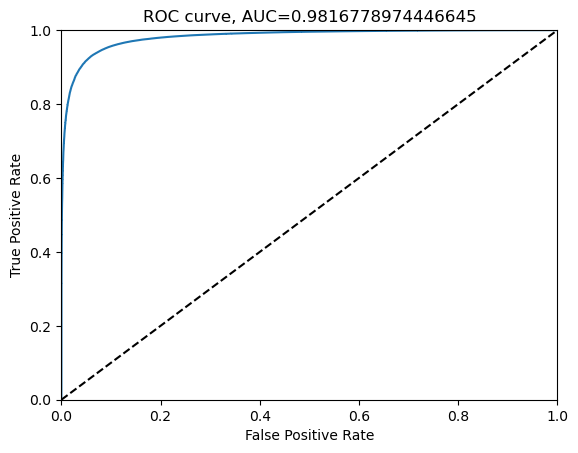

In [6]:
# make prediction
y_pred = model.predict(dval)
# AUC
fpr, tpr, thresholds = roc_curve(y_val, y_pred)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC curve, AUC={roc_auc}')

##### 5.2 Confusion matrix

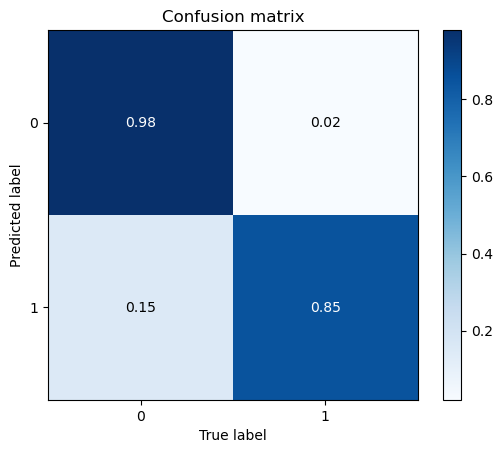

In [7]:
# confusion matrix
y_pred_binary = y_pred > 0.5
cm = confusion_matrix(y_val, y_pred_binary)
cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
#plt
plt.figure()
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
#add text
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], '.2f'),
                 ha="center", va="center",
                 color="white" if cm[i, j] > thresh else "black")
plt.title('Confusion matrix')
plt.colorbar()
plt.xlabel('True label')
plt.ylabel('Predicted label')
plt.xticks([0, 1])
plt.yticks([0, 1])
plt.show()


##### 5.3 Score distribution

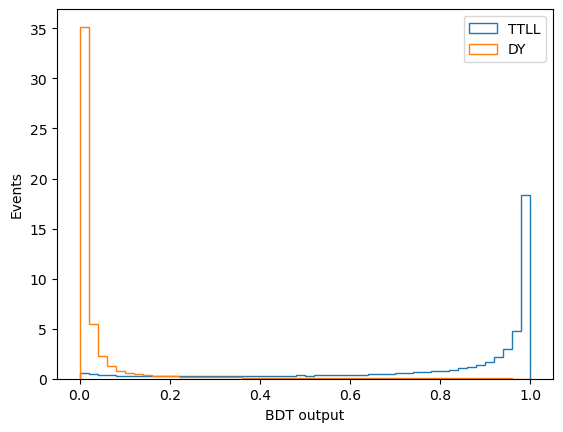

In [8]:
#distribution of the output

y_pred = model.predict(dval)
y_pred_sig = y_pred[y_val == 1]
y_pred_bkg = y_pred[y_val == 0]
plt.figure()
plt.hist(y_pred_sig, bins=50, histtype='step', label='TTLL', density=True)
plt.hist(y_pred_bkg, bins=50, histtype='step', label='DY', density=True)
plt.legend(loc='best')
plt.xlabel('BDT output')
plt.ylabel('Events')
plt.show()


##### 5.4 Feature importance

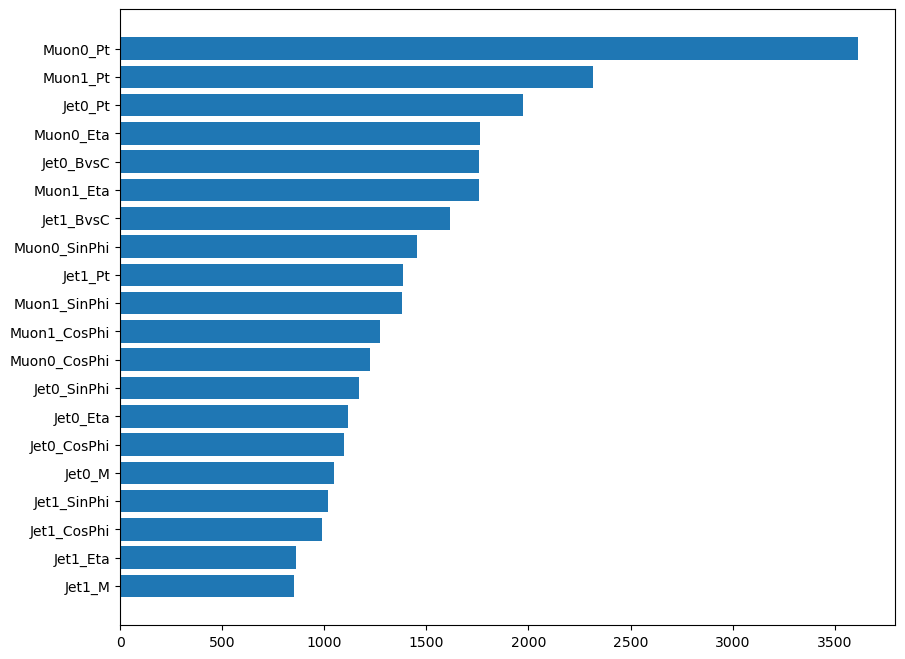

In [9]:
#get feature importance
fig, ax = plt.subplots(figsize=(10, 8))
feature_importance = model.get_score(importance_type='weight')
feature_importance = dict(sorted(feature_importance.items(), key=lambda x: x[1], reverse=False))
feature_importance_idx = [int(k) for k in feature_importance.keys()]
feature_importance_val = list(feature_importance.values())
used_columns = np.array(used_columns)
used_columns = used_columns[feature_importance_idx]
ax.barh(used_columns, feature_importance_val)
plt.show()



#### 6. Save the model as ONNX format

This is one of the most trickiest part in this workflow.

In [10]:

model_onnx = convert_xgboost_booster(
    model,
    initial_types=[('input', FloatTensorType([None, X_train.shape[1]]))],
    target_opset=15
)
# Due to a bug in onnxmltools, we need to manually set the output shape
model_onnx.graph.output[1].type.tensor_type.shape.dim[1].dim_value = 2
onnx.save_model(model_onnx, "model_xgboost_gpu.onnx")


Let's check the converted model gives same result as the original model.

In [11]:
import onnxruntime as rt

In [12]:
# infer with onnxruntime, get score
import onnxruntime as rt
sess = rt.InferenceSession("model_xgboost_gpu.onnx")

input_name = sess.get_inputs()[0].name
label_name = sess.get_outputs()[0].name
score_name = sess.get_outputs()[1].name

X_val_onnx = X_val.values.astype(np.float32)
y_pred_onnx = sess.run([label_name, score_name], {input_name: X_val_onnx})[1]
y_pred_onnx = y_pred_onnx[:,1]

(array([2.34565e+05, 6.39790e+04, 1.77210e+04, 6.99800e+04, 5.84100e+03,
        2.23790e+04, 3.62000e+03, 1.29700e+04, 1.74900e+03, 7.37500e+03,
        9.76000e+02, 3.70400e+03, 2.68300e+03, 3.24000e+02, 1.22200e+03,
        2.06000e+02, 6.82000e+02, 1.48000e+02, 3.63000e+02, 7.80000e+01,
        2.14000e+02, 4.70000e+01, 1.19000e+02, 2.90000e+01, 7.60000e+01,
        2.90000e+01, 7.00000e+00, 2.00000e+01, 7.00000e+00, 1.10000e+01,
        1.00000e+00, 6.00000e+00, 2.00000e+00, 1.10000e+01, 2.00000e+00,
        2.00000e+00, 1.00000e+00, 6.00000e+00, 4.00000e+00, 0.00000e+00,
        0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00,
        0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 1.00000e+00]),
 array([0.00000000e+00, 3.21865095e-08, 6.43730189e-08, 9.65595319e-08,
        1.28746038e-07, 1.60932544e-07, 1.93119064e-07, 2.25305570e-07,
        2.57492076e-07, 2.89678582e-07, 3.21865087e-07, 3.54051593e-07,
        3.86238128e-07, 4.18424634e-07, 4.50611140e-

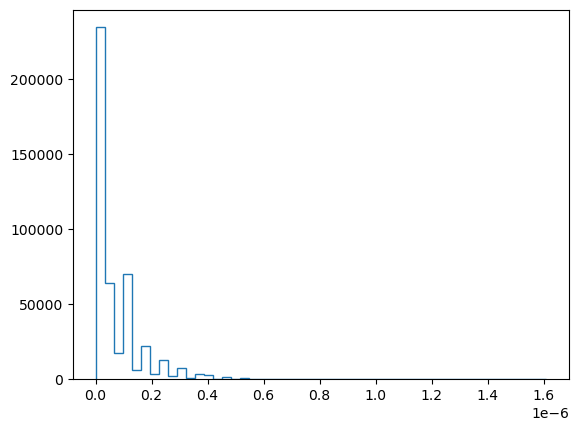

In [13]:
plt.hist(np.abs(y_pred - y_pred_onnx), bins=50, histtype='step')

It seems level of the error is within the floating point error.

### Attention Network

#### 1. Import the necessary libraries

Desired libraries are little bit different from Xgboost.

In [14]:
import ROOT
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import confusion_matrix
import pytorch_lightning as pl
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader


Preperation of the data is the same as the Xgboost. I do not repeat the same thing here.

In [15]:
df_bkg['label'] = 0
df_sig['label'] = 1
df_bkg['weight'] = 1
df_sig['weight'] = scale_pos_weight

df = pd.concat([df_sig, df_bkg], ignore_index=True)
df_train, df_val = train_test_split(df, test_size=0.2, random_state=42)

A Little differences that must be handled in use of neural network are, the data must be normalized.
Decision Tree based model robust under outliers, but neural network is not. Thus, it is necessary to normalize the data.

One most common approach is make it zero mean and unit variance, that is,

$$
x_{i,\text{norm}} = \frac{x_i - \mu}{\sigma}
$$

But if distribution has a long tail like $p_T$, It is common to apply log transformation before normalization.
Thus,
$$
x_{i,\text{norm}} = \frac{\log(x_i) - \mu_\text{log}}{\sigma_\text{log}}
$$

There are many other ways to normalize the data. It will be great to find a normalization method that is suitable for the data. However, in most cases, the above method is sufficient.

Let's precompute the parameters that related with normalization here.

In [16]:
def get_normalization_param(arr, log_transform=False):
    df = arr
    if log_transform:
        df = np.log(arr)
    mean = df.mean()
    std = df.std()
    return mean, std

In [17]:
colums = df_train.drop(columns=['label', 'weight']).columns
print(colums)
features = ['_'+col.split('_')[1] for col in colums]
features = list(set(features))
#sort
features.sort()
norm_param = {}
for feature in features:
    log_transform = False
    if '_M' in feature or '_Pt' in feature  :
        log_transform = True
    
    # concatenate all columns with the same feature name
    target_cols = [col for col in colums if feature in col]
    print(f"Will concatenate {target_cols} for feature {feature}") 
    arr = df_train[target_cols].values.flatten()
    mean, std = get_normalization_param(arr, log_transform)
    norm_param[feature] = {'val':(mean, std), 'log_transform': log_transform}
print(norm_param)
norm_param_list = [norm_param[feature] for feature in features]
print(f"From now, ordering of feature is {features}")

Index(['Jet0_BvsC', 'Jet0_CosPhi', 'Jet0_Eta', 'Jet0_M', 'Jet0_Pt',
       'Jet0_SinPhi', 'Jet0_isJet', 'Jet1_BvsC', 'Jet1_CosPhi', 'Jet1_Eta',
       'Jet1_M', 'Jet1_Pt', 'Jet1_SinPhi', 'Jet1_isJet', 'Muon0_BvsC',
       'Muon0_CosPhi', 'Muon0_Eta', 'Muon0_M', 'Muon0_Pt', 'Muon0_SinPhi',
       'Muon0_isJet', 'Muon1_BvsC', 'Muon1_CosPhi', 'Muon1_Eta', 'Muon1_M',
       'Muon1_Pt', 'Muon1_SinPhi', 'Muon1_isJet'],
      dtype='str')
Will concatenate ['Jet0_BvsC', 'Jet1_BvsC', 'Muon0_BvsC', 'Muon1_BvsC'] for feature _BvsC
Will concatenate ['Jet0_CosPhi', 'Jet1_CosPhi', 'Muon0_CosPhi', 'Muon1_CosPhi'] for feature _CosPhi
Will concatenate ['Jet0_Eta', 'Jet1_Eta', 'Muon0_Eta', 'Muon1_Eta'] for feature _Eta
Will concatenate ['Jet0_M', 'Jet1_M', 'Muon0_M', 'Muon1_M'] for feature _M
Will concatenate ['Jet0_Pt', 'Jet1_Pt', 'Muon0_Pt', 'Muon1_Pt'] for feature _Pt
Will concatenate ['Jet0_SinPhi', 'Jet1_SinPhi', 'Muon0_SinPhi', 'Muon1_SinPhi'] for feature _SinPhi
Will concatenate ['Jet0_isJet', 'J

now `norm_param` contains the mean and standard deviation of each feature. For Mass and $p_T$, log transformation is applied before normalization.


Before create the model, reshape the data as 4*6, that is, 4 objects and 6 features. And change the data to torch tensor.

In [18]:
def extract_features(row):
    objects = ['Jet0', 'Jet1', 'Muon0', 'Muon1']
    feature_list = []
    for obj in objects:
        fs = []
        for feature in features:
            fs.append(row[f'{obj}{feature}'])
        feature_list.append(fs)
    return feature_list  # List of lists: [[Jet0 features], [Jet1 features], [Muon0], [Muon1]]


In [19]:
class PhysicsDataset(Dataset):
    def __init__(self, dataframe):
        self.features = torch.tensor(
            dataframe.apply(extract_features, axis=1).tolist(),
            dtype=torch.float32
        )  # Shape: (num_samples, 4, 6)
        self.weights = torch.tensor(
            dataframe['weight'].values,
            dtype=torch.float32
        )  # Shape: (num_samples,)
        # If you have labels, include them here
        # self.labels = torch.tensor(dataframe['label'].values, dtype=torch.long)
        self.ys = torch.tensor(dataframe['label'].values, dtype=torch.float32)
    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        # Return features and weight (and label if available)
        return {
            'features': self.features[idx],
            'weights': self.weights[idx],
            'ys': self.ys[idx]
        } 
        # If labels are available:
        # return self.features[idx], self.weights[idx], self.labels[idx]


In [20]:
train_dataset = PhysicsDataset(df_train)
val_dataset = PhysicsDataset(df_val)

in torch, `DataLoader` is used to load the data.

In [21]:
train_dataloader = DataLoader(train_dataset, batch_size=2, shuffle=True)
batch = next(iter(train_dataloader)) 
batch['features'].shape, batch['weights'].shape

(torch.Size([2, 4, 7]), torch.Size([2]))

#### 2. Create a model

Now Let's create a model. I'll use class token to represent the event. This method is used in CaiT and BERT model, and also for ParticleTransformer.

Overall structure of the model is as follows:
1. Normalizing Layer, which is used to normalize the input data using the `norm_param`.
2. Embedding Layer, which is used to embed the input data. Fully-connected layer is used to embed the input data. It maps the input data to the hidden dimension.
3. Attention Layer, which is used to calculate the attention score. Class token and the embedded data are concatenated and fed to the attention layer. 
4. MLP Layer, which is used to calculate the output. Resulting class token is fed to the MLP layer to get the classification result.


In [22]:
# normalization layer
class NormalizationLayer(torch.nn.Module):
    def __init__(self, mean, std, log_transform=False):
        super(NormalizationLayer, self).__init__()
        self.mean = torch.nn.Parameter(torch.tensor(mean), requires_grad=False)
        self.std = torch.nn.Parameter(torch.tensor(std), requires_grad=False)
        self.log_transform = log_transform
        
    def forward(self, x):
        #handle 0 std
        if self.std == 0:
            if self.log_transform:
                x = torch.log(x) - self.mean
            else:
                x = x - self.mean

        if log_transform:
            x = torch.log(x)
        return (x - self.mean) / self.std




In [23]:
import torch
import torch.nn as nn
import torch.nn.functional as F
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 3090


In [24]:
import torch
import torch.nn as nn
import torch.nn.functional as F
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

class AttentionBlock(nn.Module):
    def __init__(self, hidden_dim, num_heads=1, ff_multiplier=4, dropout=0.1):
        super().__init__()

        # --- Sub-layer 1: Multi-Head Attention ---
        self.attn = nn.MultiheadAttention(hidden_dim, num_heads, batch_first=True)
        self.norm1 = nn.LayerNorm(hidden_dim)


        # --- Sub-layer 2: Feed Forward (MLP) ---
        self.ff = nn.Sequential(
            nn.Linear(hidden_dim, ff_multiplier * hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(ff_multiplier * hidden_dim, hidden_dim),
            nn.Dropout(dropout),
        )
        self.norm2 = nn.LayerNorm(hidden_dim)

    def forward(self, x):
        # Sub-layer 1 (Multihead Attn)
        mha_in = self.norm1(x)                    # pre-norm
        attn_out, _ = self.attn(mha_in, mha_in, mha_in)
        x = x + attn_out        # skip

        # Sub-layer 2 (Feed Forward)
        ff_in = self.norm2(x)                     # pre-norm
        ff_out = self.ff(ff_in)
        x = x + ff_out
        return x



True
NVIDIA GeForce RTX 3090


In [25]:
class AttentionExample(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, norm_param_list):
        super().__init__()

        # Build a normalization layer for each column
        self.norm_layers = nn.ModuleList()
        self.len_seq = 4
        for vals in norm_param_list: 
            mean, std = vals['val']
            log_transform = vals['log_transform']
            print(f"Initalizing NormalizationLayer with mean={mean}, std={std}, log_transform={log_transform}")
            self.norm_layers.append(NormalizationLayer(mean, std, log_transform))


        # A simple embedding (MLP) stack
        # Using nn.Sequential for convenience
        self.embedding = nn.Sequential(
            nn.Linear(input_dim, input_dim * 2),
            nn.LayerNorm(input_dim * 2),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(input_dim * 2, hidden_dim // 2),
            nn.LayerNorm(hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim // 2, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU()
        )

        # Class token as a learnable parameter
        self.class_token = nn.Parameter(torch.randn(hidden_dim), requires_grad=True)

        # MultiheadAttention defaults to (S, N, E); set batch_first=True to use (N, S, E)
        self.Attention1 = AttentionBlock(hidden_dim, num_heads=4)
        self.Attention2 = AttentionBlock(hidden_dim, num_heads=4)
        self.Attention3 = AttentionBlock(hidden_dim, num_heads=4)

        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim//2),
            nn.LayerNorm(hidden_dim//2),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim//2, hidden_dim//4),
            nn.LayerNorm(hidden_dim//4),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim//4, output_dim)
        )
        


    def forward(self, x):
        """
        Expects x to have shape [batch_size, 4(sequence length, 2(muons)+2(jets)+1),num_features].
        We apply each column's normalization, then pass the combined
        result through an embedding MLP, and finally multihead attention.
        """
        # 1) Normalize each feature column
        for i in range(x.shape[2]):
            x[:, :, i] = self.norm_layers[i](x[:, :, i])
        
        #do embedding for each object
        x = [self.embedding(x[:, i, :]) for i in range(self.len_seq)]
        x = torch.stack(x, dim=1)  # [batch_size, self.len_seq, hidden_dim]

        # 3) Add class token. We treat the entire MLP output as a single "token",
        #    so we end up with 2 tokens per sample: [class_token, x_token].
        batch_size = x.shape[0]
        cls_token = self.class_token.unsqueeze(0).unsqueeze(1)  # [1,1,hidden_dim]
        cls_token = cls_token.repeat(batch_size, 1, 1)          # [batch_size, 1, hidden_dim]
        x = torch.cat([cls_token, x], dim=1)                   # [batch_size, 2(muons)+2(jets)+1, hidden_dim]

        # 4) Multihead attention layers (still [batch_size, 2, hidden_dim])
        x = self.Attention1(x)
        x = self.Attention2(x)
        x = self.Attention3(x)


        # 5) Take the class token (index 0) => [batch_size, hidden_dim]
        x = x[:, 0, :]

        # 6) Final linear layer for classification/regression => [batch_size, output_dim]
        x = self.fc(x)
        return x

In [26]:
#now do the training with pytorch_lightning

class AttentionExampleModel(pl.LightningModule):
    def __init__(self, input_dim, hidden_dim, output_dim, norm_param):
        super().__init__()
        self.model = AttentionExample(input_dim, hidden_dim, output_dim, norm_param)
        self.loss_fn = nn.CrossEntropyLoss(reduction='none')
        self.save_hyperparameters()
        

    def compute_loss(self, y_pred, y, w):
        y = y.long()
        loss = self.loss_fn(y_pred, y)  # Shape: (batch_size,)
        weighted_loss = loss * w
        return weighted_loss.mean()
    
    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        x = batch['features']
        y = batch['ys']
        w = batch['weights']
        y_pred = self(x)
        loss = self.compute_loss(y_pred, y, w)
        self.log('train_loss', loss, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x = batch['features']
        y = batch['ys']
        w = batch['weights']
        y_pred = self(x)
        loss = self.compute_loss(y_pred, y, w)
        self.log('val_loss', loss, on_step=False, on_epoch=True, prog_bar=True)

        return loss

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=1e-3)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
        # Strongly recommend to use a scheduler.
        return {
            'optimizer': optimizer,
            'lr_scheduler': {
                'scheduler': scheduler,
                'monitor': 'val_loss'
            }
        }


train_dataloader = DataLoader(train_dataset, batch_size=512, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=512)
#early stopping
early_stopping = pl.callbacks.EarlyStopping(monitor='val_loss', patience=10, mode='min')
#get best model
checkpoint_callback = pl.callbacks.ModelCheckpoint(
    monitor="val_loss",  # Metric to monitor
    mode="min",          # Save the model with the minimum validation loss
    save_top_k=1,        # Save only the best model
    dirpath="checkpoints_gpu",  # Directory to save the checkpoints
    filename="best_model",  # Name of the best model file
    save_weights_only=False,  # Save the full model (architecture + weights)
)
# model = AttentionExampleModel(input_dim=7, hidden_dim=128, output_dim=2, norm_param=norm_param_list)
# trainer = pl.Trainer(max_epochs=100, accelerator="gpu", devices=1, callbacks=[early_stopping, checkpoint_callback], detect_anomaly=False)
# trainer.fit(model, train_dataloader, val_dataloader)



#### 5. Do evaluation

In [27]:
best_model_path = "/data9/Users/eunsu/MachineLearning/notebooks/checkpoints_gpu/best_model.ckpt"
print("1 load start")
best_model = AttentionExampleModel.load_from_checkpoint(
    best_model_path,
    input_dim=7,
    hidden_dim=128,
    output_dim=2,
    norm_param=norm_param_list,
    weights_only=False,
    map_location="cpu"
)
print("2 load done")

best_model.eval()
best_model.to("cpu")
print("3 model ready")

it = iter(val_dataloader)
print("4 iter made")

batch = next(it)
print("5 batch loaded")

x = batch["features"][:10].float().contiguous().to("cpu")
print("6 x ready", x.shape)

with torch.no_grad():
    out = best_model(x)
print("7 forward done", out.shape)

1 load start
Initalizing NormalizationLayer with mean=0.21017464995384216, std=0.38251233100891113, log_transform=False
Initalizing NormalizationLayer with mean=-0.00034362723818048835, std=0.7074353694915771, log_transform=False
Initalizing NormalizationLayer with mean=-0.00046896934509277344, std=1.1467097997665405, log_transform=False
Initalizing NormalizationLayer with mean=0.02815604768693447, std=2.3000147342681885, log_transform=True
Initalizing NormalizationLayer with mean=4.156110763549805, std=0.5479974150657654, log_transform=True
Initalizing NormalizationLayer with mean=-0.00013135965855326504, std=0.7067779302597046, log_transform=False
Initalizing NormalizationLayer with mean=0.5, std=0.5, log_transform=False
2 load done
3 model ready
4 iter made
5 batch loaded
6 x ready torch.Size([10, 4, 7])


: 

As same as before, evaluate the model using the test data.

In [ ]:
#get model with the best validation loss
# Load the best model after training
best_model_path = "/data9/Users/eunsu/MachineLearning/notebooks/checkpoints_gpu/best_model.ckpt"
print(f"Best model saved at: {best_model_path}")
# Load the best model
best_model = AttentionExampleModel.load_from_checkpoint(best_model_path, input_dim=7, hidden_dim=128, output_dim=2, norm_param=norm_param_list, weights_only=False)

best_model.eval()
best_model.to("cpu")

batch = next(iter(val_dataloader))
x = batch["features"][:10].float().contiguous().to("cpu")

with torch.no_grad():
    out = best_model(x)

print(out.shape)
print(out[:3])

Best model saved at: /data9/Users/eunsu/MachineLearning/notebooks/checkpoints_gpu/best_model.ckpt
Initalizing NormalizationLayer with mean=0.21017464995384216, std=0.38251233100891113, log_transform=False
Initalizing NormalizationLayer with mean=-0.00034362723818048835, std=0.7074353694915771, log_transform=False
Initalizing NormalizationLayer with mean=-0.00046896934509277344, std=1.1467097997665405, log_transform=False
Initalizing NormalizationLayer with mean=0.02815604768693447, std=2.3000147342681885, log_transform=True
Initalizing NormalizationLayer with mean=4.156110763549805, std=0.5479974150657654, log_transform=True
Initalizing NormalizationLayer with mean=-0.00013135965855326504, std=0.7067779302597046, log_transform=False
Initalizing NormalizationLayer with mean=0.5, std=0.5, log_transform=False


In [ ]:
#get model with the best validation loss
# Load the best model after training
best_model_path = "/data9/Users/eunsu/MachineLearning/notebooks/checkpoints_gpu/best_model.ckpt"
print(f"Best model saved at: {best_model_path}")
# Load the best model
best_model = AttentionExampleModel.load_from_checkpoint(best_model_path, input_dim=7, hidden_dim=128, output_dim=2, norm_param=norm_param_list, weights_only=False)
best_model.eval()
best_model.to('cpu')
with torch.no_grad():
    y_pred = []
    y_val = []
    for i, batch in enumerate(val_dataloader):

    if i > 100:
        break

    x = batch['features'].to("cpu")

    y_pred.append(best_model(x).detach().cpu().numpy())
    y_val.append(batch['ys'].detach().cpu().numpy())


#    for batch in val_dataloader:
#        x = batch['features'].to("cpu")
#        y_pred.append(best_model(x).detach().cpu().numpy())
#        y_val.append(batch['ys'].detach().cpu().numpy())
#    y_pred = np.concatenate(y_pred)
#    y_val = np.concatenate(y_val).astype(int)

    # Because we not apply softmax in the model, we need to apply softmax here
    y_pred = np.exp(y_pred) / np.exp(y_pred).sum(axis=1)[:, None]
    y_pred = y_pred[:, 1]

Best model saved at: /data9/Users/eunsu/MachineLearning/notebooks/checkpoints_gpu/best_model.ckpt
Initalizing NormalizationLayer with mean=0.21017464995384216, std=0.38251233100891113, log_transform=False
Initalizing NormalizationLayer with mean=-0.00034362723818048835, std=0.7074353694915771, log_transform=False
Initalizing NormalizationLayer with mean=-0.00046896934509277344, std=1.1467097997665405, log_transform=False
Initalizing NormalizationLayer with mean=0.02815604768693447, std=2.3000147342681885, log_transform=True
Initalizing NormalizationLayer with mean=4.156110763549805, std=0.5479974150657654, log_transform=True
Initalizing NormalizationLayer with mean=-0.00013135965855326504, std=0.7067779302597046, log_transform=False
Initalizing NormalizationLayer with mean=0.5, std=0.5, log_transform=False


: 

##### 5.1. ROC curve

Text(0.5, 1.0, 'ROC curve, AUC=0.942727892516048')

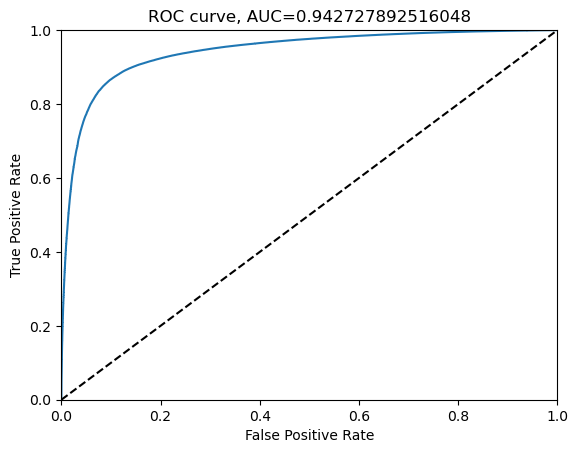

In [29]:
fpr, tpr, thresholds = roc_curve(y_val, y_pred)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC curve, AUC={roc_auc}')

##### 5.2 Confusion matrix

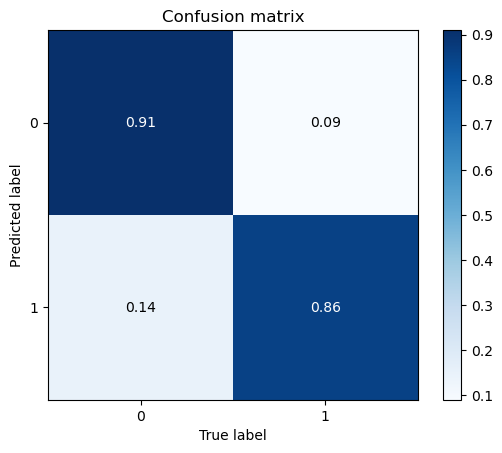

In [30]:
y_pred_binary = y_pred > 0.5
cm = confusion_matrix(y_val, y_pred_binary)
cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
#plt
plt.figure()
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
#add text
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], '.2f'),
                 ha="center", va="center",
                 color="white" if cm[i, j] > thresh else "black")
plt.title('Confusion matrix')
plt.colorbar()
plt.xlabel('True label')
plt.ylabel('Predicted label')
plt.xticks([0, 1])
plt.yticks([0, 1])
plt.show()


##### 5.3 Score distribution

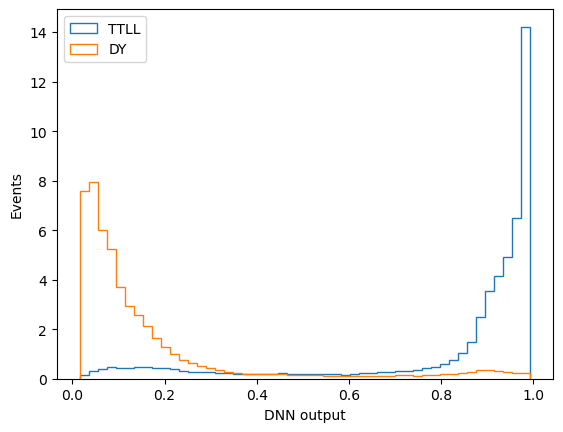

In [31]:
#distribution of the output
y_pred_sig = y_pred[y_val == 1]
y_pred_bkg = y_pred[y_val == 0]
plt.figure()
plt.hist(y_pred_sig, bins=50, histtype='step', label='TTLL', density=True)
plt.hist(y_pred_bkg, bins=50, histtype='step', label='DY', density=True)
plt.legend(loc='best')
plt.xlabel('DNN output')
plt.ylabel('Events')
plt.show()


#### 6. Save the model as ONNX format

In [35]:
import sys
!{sys.executable} -m pip install onnxscript

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 714.8/714.8 kB 33.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [onnxscript]2 [onnxscript]


In [5]:
import onnxscript

In [37]:
# save the model as onnx
dummy_input = torch.randn(1, 4, 7).to("cuda")
onnx_path = 'model_attention_gpu.onnx'
torch.onnx.export(best_model, dummy_input, onnx_path, verbose=True, input_names=['input'], output_names=['output'], dynamic_axes={"input": {0: "batch_size"}, "output": {0: "batch_size"}})

/tmp/ipykernel_378551/2844707449.py:4: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(best_model, dummy_input, onnx_path, verbose=True, input_names=['input'], output_names=['output'], dynamic_axes={"input": {0: "batch_size"}, "output": {0: "batch_size"}})


[torch.onnx] Obtain model graph for `AttentionExampleModel([...]` with `torch.export.export(..., strict=False)`...


W0521 19:29:55.234000 378551 site-packages/torch/fx/experimental/symbolic_shapes.py:8605] Unable to find user code corresponding to {u0}



def forward(self, arg0_1: "f32[128]", arg1_1: "f32[]", arg2_1: "f32[]", arg3_1: "f32[]", arg4_1: "f32[]", arg5_1: "f32[]", arg6_1: "f32[]", arg7_1: "f32[]", arg8_1: "f32[]", arg9_1: "f32[]", arg10_1: "f32[]", arg11_1: "f32[]", arg12_1: "f32[]", arg13_1: "f64[]", arg14_1: "f64[]", arg15_1: "f32[14, 7]", arg16_1: "f32[14]", arg17_1: "f32[14]", arg18_1: "f32[14]", arg19_1: "f32[64, 14]", arg20_1: "f32[64]", arg21_1: "f32[64]", arg22_1: "f32[64]", arg23_1: "f32[128, 64]", arg24_1: "f32[128]", arg25_1: "f32[128]", arg26_1: "f32[128]", arg27_1: "f32[384, 128]", arg28_1: "f32[384]", arg29_1: "f32[128, 128]", arg30_1: "f32[128]", arg31_1: "f32[128]", arg32_1: "f32[128]", arg33_1: "f32[512, 128]", arg34_1: "f32[512]", arg35_1: "f32[128, 512]", arg36_1: "f32[128]", arg37_1: "f32[128]", arg38_1: "f32[128]", arg39_1: "f32[384, 128]", arg40_1: "f32[384]", arg41

[torch.onnx] Obtain model graph for `AttentionExampleModel([...]` with `torch.export.export(..., strict=False)`... ❌
[torch.onnx] Obtain model graph for `AttentionExampleModel([...]` with `torch.export.export(..., strict=True)`...


class GraphModule(torch.nn.Module):
    def forward(self, L_flat_args_0_: "f32[s6, 4, 7][28, 7, 1]cuda:0"):
        l_flat_args_0_ = L_flat_args_0_

        # File: /tmp/ipykernel_378551/1456234938.py:60 in forward, code: for i in range(x.shape[2]):
        size = l_flat_args_0_.size()
        getitem: "Sym(s6)" = size[0];  getitem = None
        getitem_1 = size[1];  getitem_1 = None
        getitem_2 = size[2];  size = getitem_2 = None

        # File: /tmp/ipykernel_378551/1456234938.py:61 in forward, code: x[:, :, i] = self.norm_layers[i](x[:, :, i])
        getitem_3: "f32[s6, 4][28, 7]cuda:0" = l_flat_args_0_[(slice(None, None, None), slice(None, None, None), 0)];  l_flat_args_0_ = getitem_3 = None

        # File: /tmp/ipykernel_378551/3474671907.py:11 in forward, code: if self.std == 0:
        l__self____export_root_model_norm_layers_0_std: "f32[][]cuda:0" = self.L__self____export_root_model_norm_layers_0_std
        eq: "b8[][]cuda:0" = l__self____export_root_model_norm_layer

[torch.onnx] Obtain model graph for `AttentionExampleModel([...]` with `torch.export.export(..., strict=True)`... ❌


TorchExportError: Failed to export the model with torch.export. [96mThis is step 1/3[0m of exporting the model to ONNX. Next steps:
- Modify the model code for `torch.export.export` to succeed. Refer to https://pytorch.org/docs/stable/generated/exportdb/index.html for more information.
- Debug `torch.export.export` and submit a PR to PyTorch.
- Create an issue in the PyTorch GitHub repository against the [96m*torch.export*[0m component and attach the full error stack as well as reproduction scripts.

## Exception summary

<class 'torch.fx.experimental.symbolic_shapes.GuardOnDataDependentSymNode'>: Could not guard on data-dependent expression Eq(u0, 1) (unhinted: Eq(u0, 1)).  (Size-like symbols: none)

consider using data-dependent friendly APIs such as guard_or_false, guard_or_true and statically_known_true.
Caused by: (_export/non_strict_utils.py:1167 in __torch_function__)
For more information, run with TORCH_LOGS="dynamic"
For extended logs when we create symbols, also add TORCH

In [51]:
# infer with onnxruntime, get score
import onnxruntime as rt
sess = rt.InferenceSession(onnx_path)


input_name = sess.get_inputs()[0].name
label_name = sess.get_outputs()[0].name
score_name = sess.get_outputs()[0].name
#get data from the dataloader

y_pred_onnx = []
for batch in val_dataloader:
    X_val = batch['features'].numpy()
    y_val = batch['ys'].numpy()
    w_val = batch['weights'].numpy()

    y_pred_onnx.append(sess.run([score_name], {input_name: X_val})[0])
y_pred_onnx = np.concatenate(y_pred_onnx)
#Do softmax
y_pred_onnx = np.exp(y_pred_onnx) / np.exp(y_pred_onnx).sum(axis=1)[:, None]
y_pred_onnx = y_pred_onnx[:, 1]

    



(array([8.8166e+04, 1.5073e+04, 4.5960e+03, 1.8320e+03, 7.5000e+02,
        3.6300e+02, 2.3300e+02, 1.0000e+02, 5.7000e+01, 4.2000e+01,
        2.8000e+01, 1.7000e+01, 1.1000e+01, 9.0000e+00, 8.0000e+00,
        4.0000e+00, 6.0000e+00, 4.0000e+00, 2.0000e+00, 2.0000e+00,
        0.0000e+00, 1.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 1.0000e+00, 0.0000e+00, 2.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00,
        1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 2.0000e+00]),
 array([0.00000000e+00, 2.47955313e-07, 4.95910626e-07, 7.43865940e-07,
        9.91821253e-07, 1.23977657e-06, 1.48773188e-06, 1.73568731e-06,
        1.98364251e-06, 2.23159782e-06, 2.47955313e-06, 2.72750844e-06,
        2.97546376e-06, 3.22341930e-06, 3.47137461e-06, 3.71932992e-06,
        3.96728501e-06, 4.2152

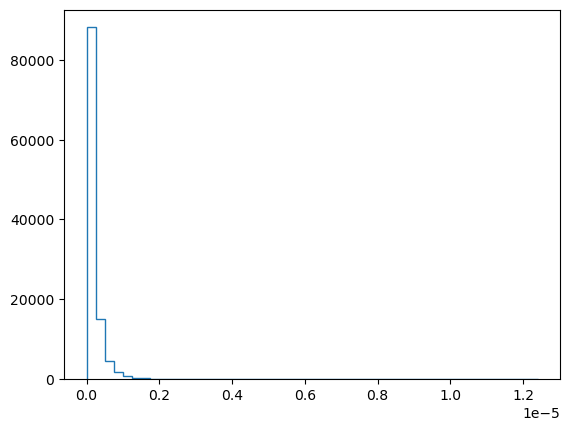

In [52]:
plt.hist(np.abs(y_pred - y_pred_onnx), bins=50, histtype='step')

Seems working well.